In [1]:
import pandas as pd
from sqlalchemy import create_engine

# Creamos la "conexión" hacia nuestra base de datos PostgreSQL
engine = create_engine('postgresql://localhost/tienda_consultora')

# Probamos la conexión con una consulta simple
pd.read_sql('SELECT * FROM clientes', engine)

,id,nombre,ciudad,fecha_registro
0,1,María González,Ciudad de México,2024-01-15
1,2,Carlos Ramírez,Guadalajara,2024-02-20
2,3,Ana Torres,Monterrey,2024-01-10
3,4,Luis Fernández,Ciudad de México,2024-03-05
4,5,Sofía Hernández,Puebla,2024-02-14
5,6,Diego Martínez,Guadalajara,2024-04-01
6,7,Valentina Cruz,Ciudad de México,2024-01-22
7,8,Andrés Morales,Querétaro,2024-03-18
8,9,Camila Reyes,Monterrey,2024-02-28
9,10,Javier Ortiz,Ciudad de México,2024-04-10


In [ ]:
query = """
SELECT
    clientes.nombre,
    SUM(productos.precio * pedidos.cantidad) AS total_gastado
FROM pedidos
JOIN clientes ON pedidos.cliente_id = clientes.id
JOIN productos ON pedidos.producto_id = productos.id
GROUP BY clientes.nombre
ORDER BY total_gastado DESC
"""

df_clientes = pd.read_sql(query, engine)
df_clientes

,nombre,total_gastado
0,Valentina Cruz,456600.0
1,Andrés Morales,325600.0
2,Diego Martínez,276300.0
3,Carlos Ramírez,257900.0
4,Luis Fernández,245600.0
5,Sofía Hernández,220800.0
6,Ana Torres,188800.0
7,Camila Reyes,178800.0
8,María González,164000.0
9,Javier Ortiz,47000.0


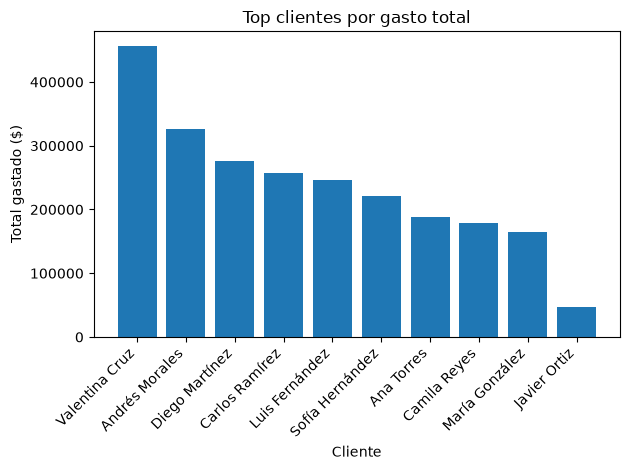

In [3]:
import matplotlib.pyplot as plt

plt.bar(df_clientes['nombre'], df_clientes['total_gastado'])
plt.xlabel('Cliente')
plt.ylabel('Total gastado ($)')
plt.title('Top clientes por gasto total')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()